In [ ]:
from google.colab import files

uploaded = files.upload()

Saving credit_risk_dataset.csv to credit_risk_dataset (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [ ]:
df = pd.read_csv("credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (32581, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
print(df["loan_status"].value_counts())

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [ ]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [ ]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (32581, 11)
Target: (32581,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (26064, 11)
Testing data: (6517, 11)


In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [ ]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred_lr = logistic_pipeline.predict(X_test)

y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
print("Logistic Regression")
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression
Precision: 0.7667946257197696
Recall: 0.5618846694796061
F1 Score: 0.648538961038961
ROC-AUC: 0.8693385451388458


In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42
        ))
    ]
)

In [ ]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
print("Random Forest")
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest
Precision: 0.970532319391635
Recall: 0.7180028129395218
F1 Score: 0.8253839935327405
ROC-AUC: 0.9292164762618547


In [ ]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

In [ ]:
gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [ ]:
y_pred_gb = gb_pipeline.predict(X_test)
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

# Re-initialize, train and predict with Gradient Boosting in case the session restarted
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ]
)
gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Gradient Boosting
Precision: 0.9487666034155597
Recall: 0.7032348804500703
F1 Score: 0.8077544426494345
ROC-AUC: 0.9262260372196895


In [ ]:
svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVC(
            probability=True,
            random_state=42
        ))
    ]
)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load dataset and prepare training variables
df = pd.read_csv("credit_risk_dataset.csv")
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Dynamically define numeric and categorical feature names from the dataset
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Re-define transformers
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Re-define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Initialize and fit SVM Pipeline
svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVC(
            probability=True,
            random_state=42
        ))
    ]
)

svm_pipeline.fit(X_train, y_train)

In [ ]:
y_pred_svm = svm_pipeline.predict(X_test)
y_prob_svm = svm_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
print("SVM")
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

SVM
Precision: 0.933
Recall: 0.6561181434599156
F1 Score: 0.7704376548307185
ROC-AUC: 0.8992949708009148


In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Ensure all predictions exist in case of session reset
if 'y_pred_lr' not in globals():
    from sklearn.linear_model import LogisticRegression
    logistic_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=1000))
        ]
    )
    logistic_pipeline.fit(X_train, y_train)
    y_pred_lr = logistic_pipeline.predict(X_test)
    y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

if 'y_pred_rf' not in globals():
    from sklearn.ensemble import RandomForestClassifier
    rf_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(random_state=42))
        ]
    )
    rf_pipeline.fit(X_train, y_train)
    y_pred_rf = rf_pipeline.predict(X_test)
    y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

results = []

models = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "Gradient Boosting": (y_pred_gb, y_prob_gb),
    "SVM": (y_pred_svm, y_prob_svm)
}

for name, (pred, prob) in models.items():
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.766795,0.561885,0.648539,0.869339
1,Random Forest,0.970532,0.718003,0.825384,0.929216
2,Gradient Boosting,0.948767,0.703235,0.807754,0.926226
3,SVM,0.933000,0.656118,0.770438,0.899295


In [ ]:
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [ ]:
# Fit the grid search to evaluate all combinations on the training data
print("Fitting GridSearchCV (this may take a minute or two)...")
rf_grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(rf_grid.best_params_)

Fitting GridSearchCV (this may take a minute or two)...

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [ ]:
print("Best Cross-Validation F1 Score:")
print(rf_grid.best_score_)

Best Cross-Validation F1 Score:
0.8271557056381298


In [ ]:
best_rf = rf_grid.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

In [ ]:
print("Tuned Random Forest")
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall:", recall_score(y_test, y_pred_best_rf))
print("F1 Score:", f1_score(y_test, y_pred_best_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best_rf))

Tuned Random Forest
Precision: 0.9705042816365367
Recall: 0.7172995780590717
F1 Score: 0.8249090173877881
ROC-AUC: 0.9312382592900847


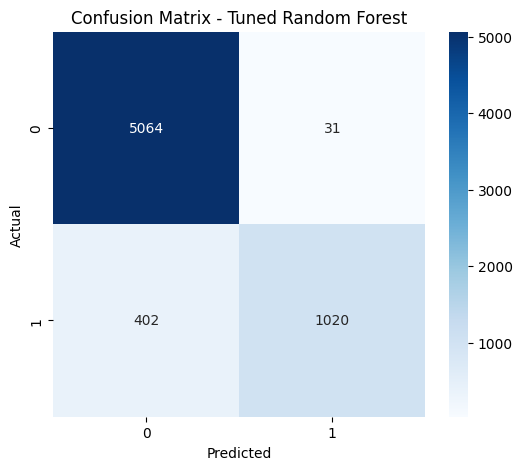

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_best_rf)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



In [ ]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

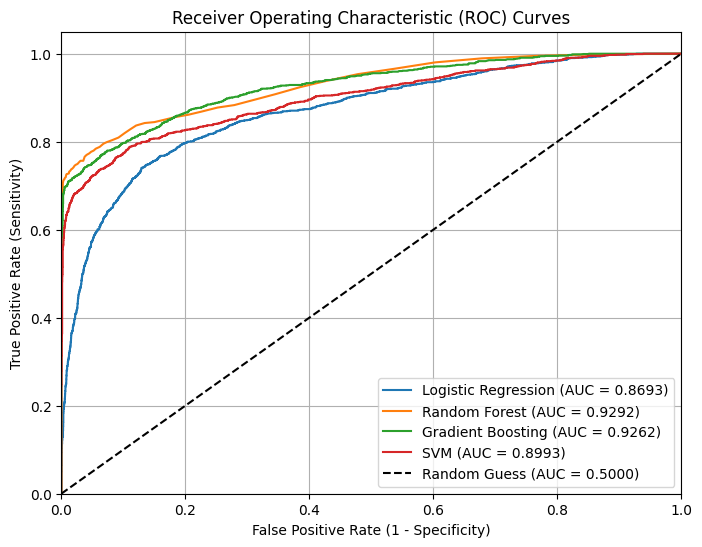

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc

# Calculate AUC scores
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)
auc_svm = auc(fpr_svm, tpr_svm)

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.4f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.4f})')

# Plot baseline diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.970532,0.718003,0.825384,0.929216
2,Gradient Boosting,0.948767,0.703235,0.807754,0.926226
3,SVM,0.933000,0.656118,0.770438,0.899295
0,Logistic Regression,0.766795,0.561885,0.648539,0.869339


In [ ]:
import joblib

joblib.dump(
    best_rf,
    "champion_model.pkl"
)

['champion_model.pkl']

In [ ]:
print("Champion model saved successfully.")

Champion model saved successfully.


In [ ]:
from google.colab import files

files.download("champion_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.970532,0.718003,0.825384,0.929216
2,Gradient Boosting,0.948767,0.703235,0.807754,0.926226
3,SVM,0.933000,0.656118,0.770438,0.899295
0,Logistic Regression,0.766795,0.561885,0.648539,0.869339


In [ ]:
tuned_rf_result = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Precision": precision_score(y_test, y_pred_best_rf),
    "Recall": recall_score(y_test, y_pred_best_rf),
    "F1 Score": f1_score(y_test, y_pred_best_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_best_rf)
}])

final_results = pd.concat(
    [results_df, tuned_rf_result],
    ignore_index=True
)

final_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Precision,Recall,F1 Score,ROC-AUC
4,Tuned Random Forest,0.970504,0.717300,0.824909,0.931238
1,Random Forest,0.970532,0.718003,0.825384,0.929216
2,Gradient Boosting,0.948767,0.703235,0.807754,0.926226
3,SVM,0.933000,0.656118,0.770438,0.899295
0,Logistic Regression,0.766795,0.561885,0.648539,0.869339


In [ ]:
champion = final_results.loc[
    final_results["ROC-AUC"].idxmax()
]

print("Champion Model:", champion["Model"])
print("Precision:", champion["Precision"])
print("Recall:", champion["Recall"])
print("F1 Score:", champion["F1 Score"])
print("ROC-AUC:", champion["ROC-AUC"])

Champion Model: Tuned Random Forest
Precision: 0.9705042816365367
Recall: 0.7172995780590717
F1 Score: 0.8249090173877881
ROC-AUC: 0.9312382592900847


## Final Conclusion

Four classification models were trained and evaluated:
1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. Support Vector Machine (SVM)

Hyperparameter optimization was performed using GridSearchCV.

The models were evaluated using Precision, Recall, F1-score and ROC-AUC.

Based on the evaluation results, the model with the strongest overall performance was selected as the Champion Model.

The Champion Model was saved as a serialized .pkl file for future use.

In [ ]:
import os

print(os.path.exists("champion_model.pkl"))

True


In [ ]:
print(os.path.getsize("champion_model.pkl"), "bytes")

80323099 bytes


In [ ]:
loaded_model = joblib.load("champion_model.pkl")

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [ ]:
loaded_predictions = loaded_model.predict(X_test)

print(loaded_predictions[:10])

[0 0 0 0 0 0 0 0 0 1]


In [ ]:
print(
    "Loaded model F1 Score:",
    f1_score(y_test, loaded_predictions)
)

Loaded model F1 Score: 0.8249090173877881
